In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
# import UserStatisticalFunctions as usf
# import UserVisualization as uv
import UserMetricsFunctions as umf

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776
REMOVE = '** REMOVE ** ALL DON'

# initialize DataFrame
df_drop = pd.DataFrame(columns=['column'])
df_date = pd.DataFrame(columns=['column'])
df_unknown = pd.DataFrame(columns=['column'])
df_numeric = pd.DataFrame(columns=['column'])
df_object = pd.DataFrame(columns=['column'])
df_label = pd.DataFrame(columns=['column'])

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Dataset

In [2]:
# import data
df = pd.read_pickle("../Data/5Clean_BeforeDummyEcode_CAT.pkl")
df_don = pd.read_pickle("../Data/5Clean_ML_DON.pkl")
df_can = pd.read_pickle("../Data/5Clean_ML_CAN.pkl")
df_both = pd.read_pickle("../Data/5Clean_ML_BOTH.pkl")
df_nominal = pd.read_pickle("../Data/5Clean_ML_nominal.pkl")
df_ordinal = pd.read_pickle("../Data/5Clean_ML_ordinal.pkl")
df_dict = pd.read_pickle("../Data/5Clean_ML_dict.pkl")

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")

Heart Dataset Rows: 15,701 & Columns: 140
Candidate Features: 66
Donor Features: 62
Both Features: 11
Nominal Features: 92
Ordinal Features: 47


In [4]:
df.head()

,PreviousTransplantNumber_CAN,BloodGroup_CAN,EducationLevel_CAN,FunctionalStatusRegistration_CAN,DiabetesType_CAN,CerebroVascularDisease_CAN,DefibrillatorImplantRegistration_CAN,CigaretteUse_CAN,PriorCardiacSurgery_CAN,StatusAtTransplant_CAN,Ethnicity_CAN,TransplantRegion,AntigenBW4_CAN,AntigenBW6_CAN,AntigenC1_CAN,AntigenC2_CAN,AntigenDR51_CAN,AntigenDR51_2_CAN,AntigenDR52_CAN,AntigenDR52_2_CAN,AntigenDR53_CAN,AntigenDR53_2_CAN,AntigenDQ1_CAN,AntigenDQ2_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,PriorLungSurgeryAfterRegistration_CAN,SteroidsUse_CAN,TransfusionAfterRegistration_CAN,Hepatitis_B_CoreAntibody_CAN,SurfaceAntigenHEP_B_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,CMVStatus_Transplant_CAN,HEP_C_SerostatusStatus_CAN,EpsteinBarrSeroStatusTransplant_CAN,HCV_NAT_PreTranspant_CAN,HBV_NAT_Result_CAN,DeceasedRetyped_DON,CrossMatchDone,AntigenDA1_DON,AntigenDA2_DON,AntigenDB1_DON,AntigenDB2_DON,AntigenDR1_DON,AntigenDR2_DON,AntigenRA1_CAN,AntigenRA2_CAN,AntigenRB1_CAN,AntigenRB2_CAN,AntigenRDR1_CAN,AntigenRDR2_CAN,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLMIS,Ethnicity_DON,Hepatitis_B_CoreAntibody_DON,SurfaceAntigenHEP_B_DON,BloodGroup_DON,HeavyAlcoholUse_DON,Antibody_HEP_C_DON,NonHeartBeating_DON,AntiHypertensive_DON,SteroidsUse_DON,TriiodothyronineT3_DON,ThyroxineT4_DON,Vasodilators_DON,AntibodyResultRPR_VDRL_DON,CigaretteHistory_DON,HypertensionHistory_DON,Diabetes_DON,SerologyAntiCMV_DON,DeathCircumstance_DON,DeathMechanism_DON,HeparinManagement_DON,ArginnieManagement_DON,InsulinManagement_DON,HBV_NAT_Result_DON,HCV_NAT_Result_DON,TransplantType_CAN,BloodGroupMatchLevel,PrimaryDiagnosisType_CAN,AllocationType_DON,PriorCardiacSurgeryListAndTransplant_CAN,Malignancy_CAN,HeartProcedureType_CAN,UrinePortein_DON,CardiacArrest_DON,MyocardialInfarctionHistory_DON,LV_EjectionFractionMedthod_DON,CoronaryAngiogram_DON,Tatoos_DON,AntibodyResultHBSAB_DON,InotropicAgent_DON,KidneyAllocation_DON,IntropicMedicationProcurement_DON,TransfusionNumber_DON,PulmonaryCatheter_DON,ChestXray_DON,Survival,Age_CAT_CAN,Age_CAT_DON,HeightCm_CAT_CAN,HeightCm_CAT_DON,WeightKg_CAT_CAN,WeightKg_CAT_DON,BMI_CAT_CAN,BMI_CAT_DON,BloodPH_CAT_DON,BloodUreaNitrogenLevel_CAT_DON,PanelReactiveAntibody_CPRA_CAT_CAN,Creatinine_CAT_CAN,Creatinine_CAT_DON,DistanceFromDonorHospitaltoTXCenter_CAT,Hematocrit_CAT_DON,Hemodynamics_Mean_PA_MN_CAT_CAN,Hemodynamics_Mean_CO_CAT_CAN,IschemicTimeHour_CAT,LV_EjectionFractionPercent_CAT_DON,SGOT_AST_Log_Addtion_CAT_DON,LungPO2_Addtion_CAT_DON,OrganRecovery_PCO2_CAT_DON,Bilirubin_CAT_CAN,Bilirubin_CAT_DON,TotalDayWaitList_CAT_CAN,Bronchoscopy_Combine_Count_DON,Cancer_Combined_Count_DON,Citizenship_Difference,DrugUse_Combnine_Count_DON,Dialysis_Combine_Count_CAN,Diuretics_Combine_Count_CAN,EpsteinBarr_Combine_Count_DON,Gender_Difference,Infection_Combine_Count_CAN,IntropesIV_Combine_Count_CAN,IntropesVasodilators_Combine_Count_CAN,LifeSupport_Combine_Count_CAN,PriorCardiacSurgery_Combine_Count_CAN,Ventilator_Combine_Count_CAN,WorkIncome_Combine_Count_CAN
0,0.0,B,5.0,5.0,Type II,No,Yes,Yes,2,Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,Asian,Region 5,Positive,Positive,Positive,Positive,Positive,Negative,Negative,Negative,Negative,Negative,Positive,Positive,3.0,1.0,No,No,No,Unknown,Negative,Missing,Positive,Negative,Positive,Unknown,Unknown,Yes,Yes,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,3.0,3.0,3.0,7.0,"White, Non-Hispanic",Negative,Negative,O,No,Negative,No,No,Yes,No,Yes,No,Negative,No,Yes,No,Positive,NONE OF THE ABOVE,NONE OF THE ABOVE,No,No,Yes,Negative,Negative,O,Compatible,DILATED MYOPATHY: IDIOPATHIC,Local,2,No,Orthotopic Bicaval,No,No,No,Echo,Normal,No,Unknown,Neosynephrine,No,Yes,1.0,No,Abnormal,Living,1.0,3.0,1.0,0.0,2.0,1.0,2.0,3.0,Normal,2.0,1.0,2.0,2.0,1.0,0.0,2.0,0.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,10.0,1,1,4.0,5.0,6.0,0,11.0,0.0,20.0,28.0,4

In [5]:
# initialize removeCols list
removeCols = df_don.column.to_list()

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 62 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 17 row(s) from df_ordinal DataFrame.
Remove 45 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_CAT_DON', 'AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDR1_DON', 'AntigenDR2_DON', 'ArginnieManagement_DON', 'BMI_CAT_DON', 'Bilirubin_CAT_DON', 'BloodGroup_DON', 'BloodPH_CAT_DON', 'BloodUreaNitrogenLevel_CAT_DON', 'Bronchoscopy_Combine_Count_DON', 'Cancer_Combined_Count_DON', 'CardiacArrest_DON', 'ChestXray_DON', 'CigaretteHistory

### Dummy Encoding

In [6]:
# encode
df_dummy = pd.get_dummies(df, columns=df_nominal.column.to_list(), drop_first=True)
# print shape
print(f"Shape: {df_dummy.shape}")
# add columns to list
dummyCols = df_dummy.columns.tolist()
# remove label
dummyCols.remove('Survival')
# create DataFrame
varDF = pd.DataFrame(columns=['ColumnName', 'Variance'])

Shape: (15701, 182)


In [7]:
for col in dummyCols:
    variance = df_dummy[col].var()
    # store the result
    result = {'ColumnName': col, 'Variance': variance}
    varDF.loc[len(varDF)] = result

varDF = varDF.sort_values(by='Variance', ascending=False)

In [8]:
lowVar = varDF.ColumnName[varDF.Variance < .01].to_list()
len(lowVar)

53

In [9]:
df_dummy = df_dummy.drop(columns=lowVar)

### Split Dataset

In [10]:
from sklearn.model_selection import train_test_split

# split X & y
X = df_dummy.drop(columns = 'Survival')
y = df_dummy.Survival

# mapping values
y = y.map({'Dead': True, 'Living': False})

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### RandomForestClassifier

In [11]:
from sklearn.ensemble import RandomForestClassifier
# function from sklearn.utils.class_weight computes the weights for each class to handle imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

# the 'balanced' mode adjusts weights inversely proportional to class frequencies in the input data for Random Forest
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# grid search Hyperparameters Random Forest Classfiier
parameters = {
    'n_estimators': [100, 300, 500],
    'min_samples_split': [30, 40, 50],
    'min_samples_leaf': [8, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 7]
}


# Initialize Model with class weights
rfc_param = {'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
model = RandomForestClassifier(**rfc_param)

# CV with grid search for Hyper-Parameter tuning
rfc_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score = 'accuracy')

# best model
model = rfc_fit.best_estimator_

CV accuracy: 0.774 +/- 0.013


In [12]:
print(model)

RandomForestClassifier(class_weight={False: 0.9487838042000302,
                                     True: 1.057061100824777},
                       max_depth=7, min_samples_leaf=15, min_samples_split=50,
                       n_estimators=500, random_state=1776)


#### Train`

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.69      0.77      6619
        True       0.72      0.88      0.79      5941

    accuracy                           0.78     12560
   macro avg       0.79      0.78      0.78     12560
weighted avg       0.79      0.78      0.78     12560



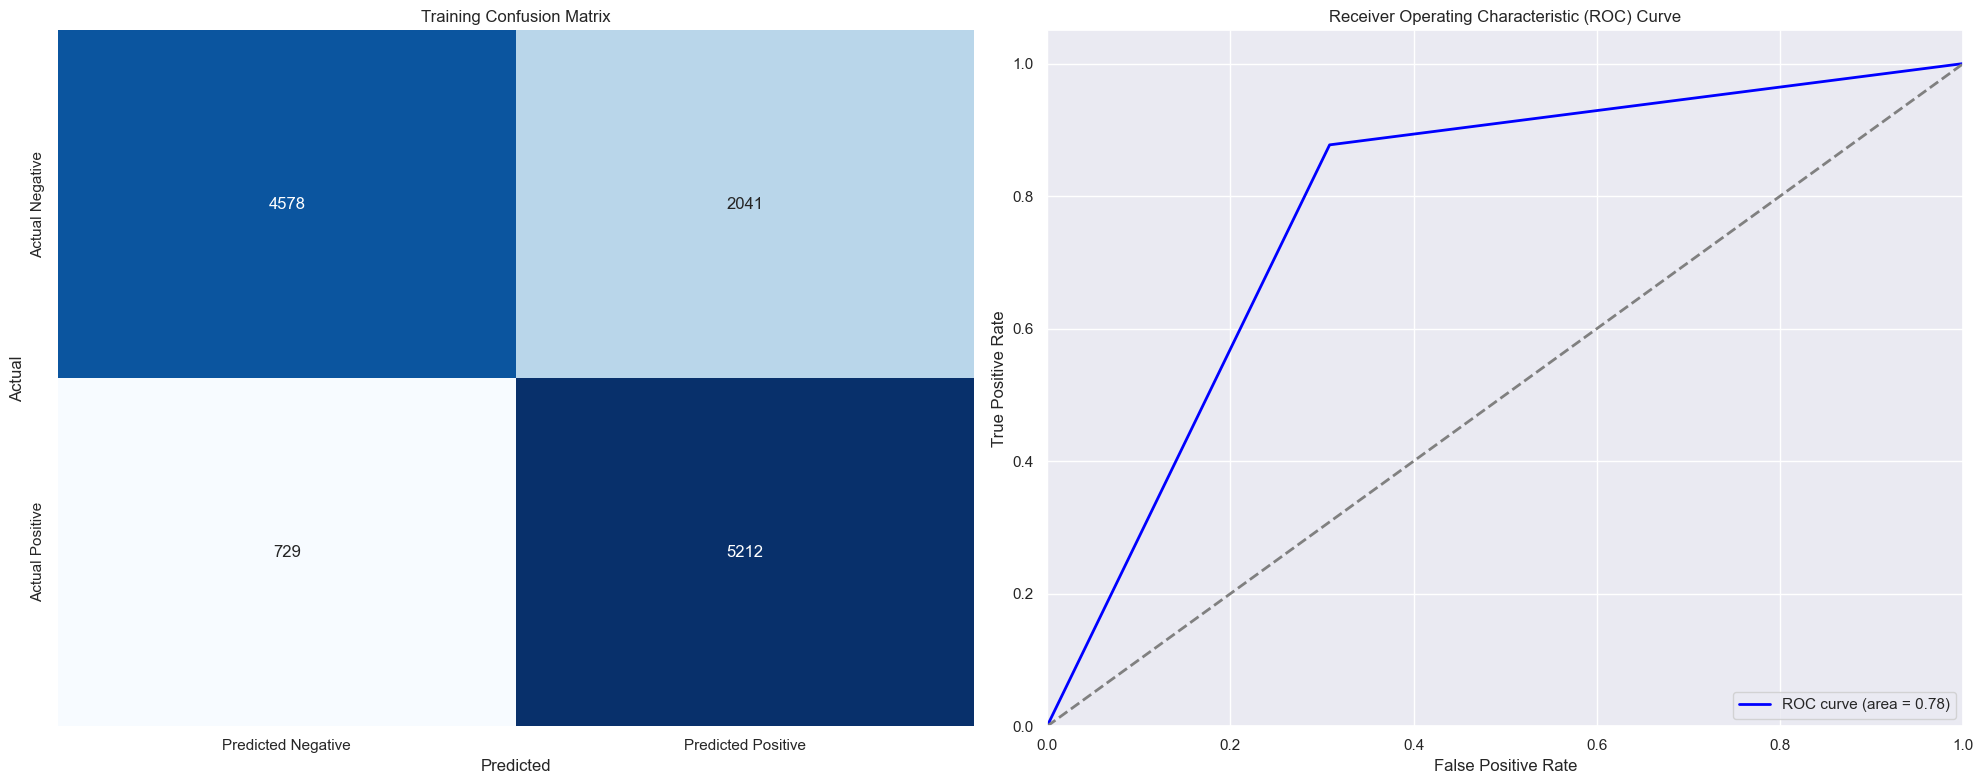

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469


In [13]:
# initialize variables
Algorithm = 'RandomForestClassifier'
Desc = 'RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed'
Model = 'rfc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=None)
df_classfication

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.68      0.76      1655
        True       0.71      0.88      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.78      0.78      3141
weighted avg       0.79      0.78      0.77      3141



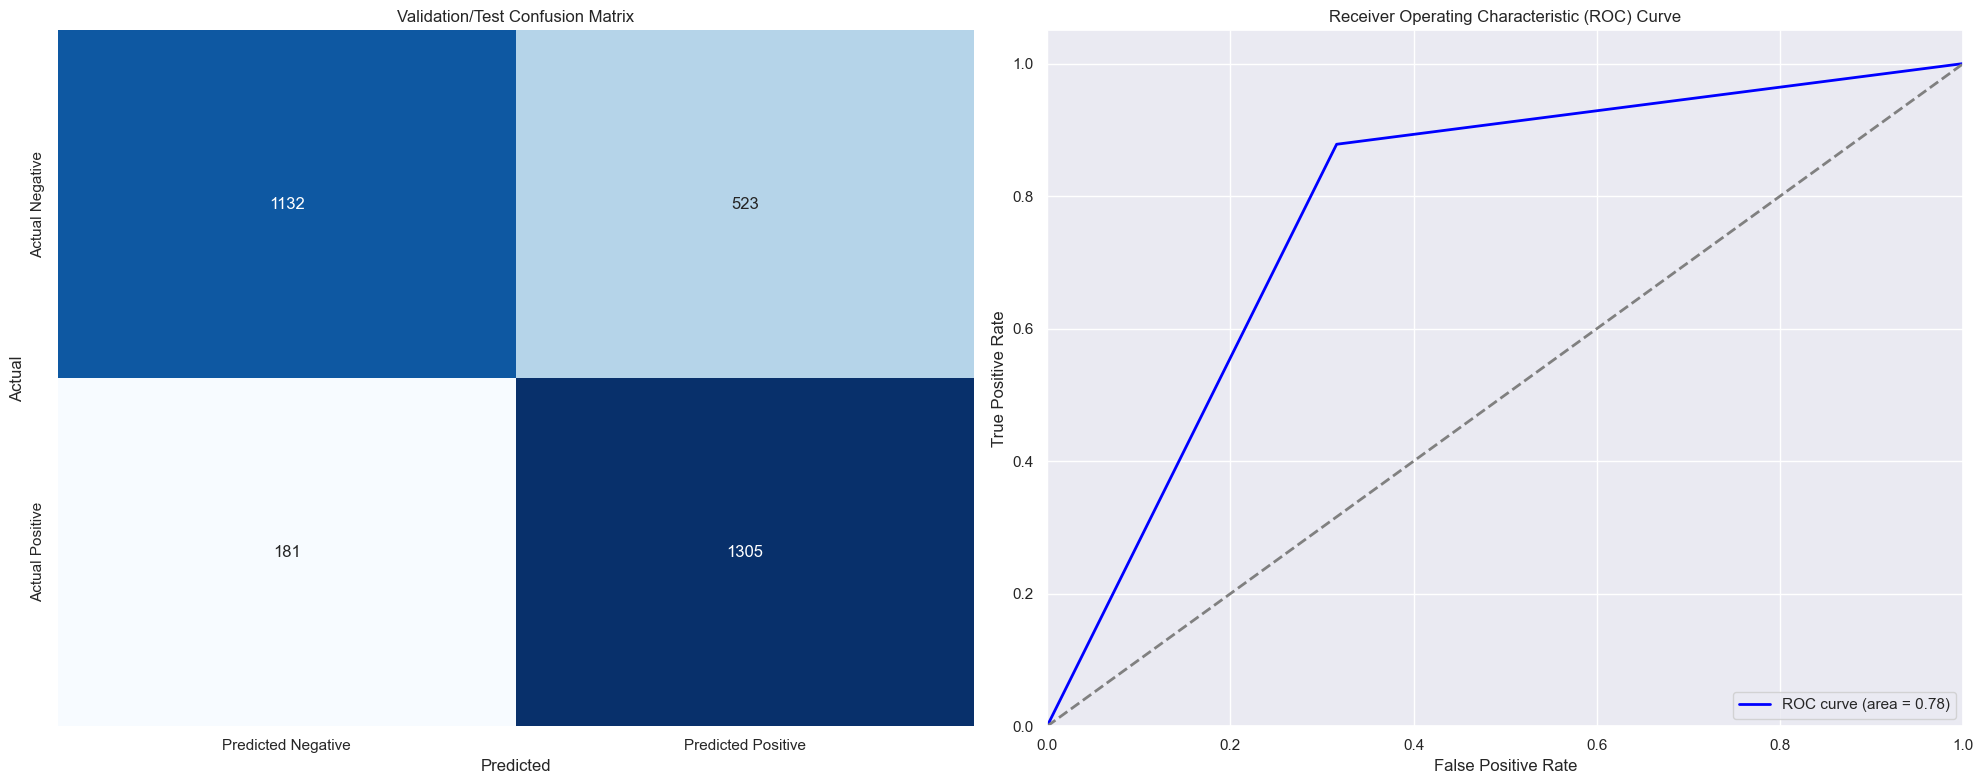

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092


In [14]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, df_classfication)
df_classfication

### LogisticRegression

In [15]:
# import library
from sklearn.linear_model import LogisticRegression

# define the hyperparameter grid to search
parameters = dict(
C = list(np.round(np.linspace(0.01, 5, 20),2))
)

# Base Model
lrc_param = {'max_iter':10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate LogisticRegression Classifier
model = LogisticRegression(**lrc_param)

# CV with grid search for Hyper-Parameter tuning
lrc_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = lrc_fit.best_estimator_

CV accuracy: 0.772 +/- 0.009


In [16]:
print(model)

LogisticRegression(C=0.54,
                   class_weight={False: 0.9487838042000302,
                                 True: 1.057061100824777},
                   max_iter=10000, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.68      0.76      6619
        True       0.71      0.88      0.79      5941

    accuracy                           0.78     12560
   macro avg       0.79      0.78      0.78     12560
weighted avg       0.79      0.78      0.78     12560



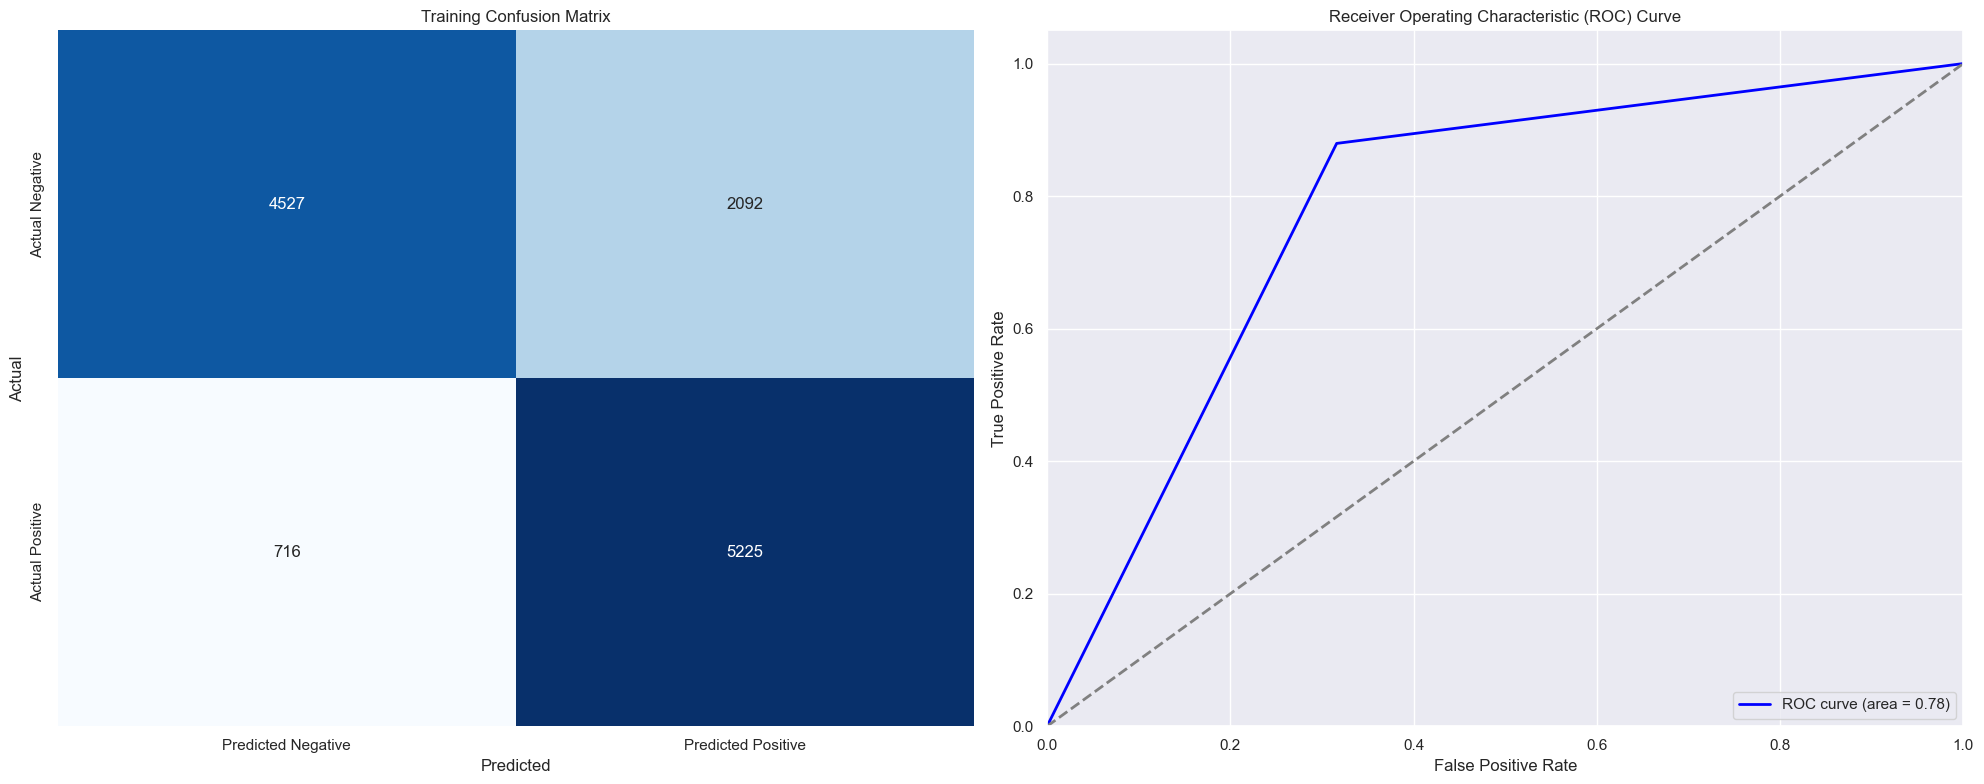

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711


In [17]:
# initialize variables
Algorithm = 'LogisticRegression'
Desc = 'LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed'
Model = 'lrc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.68      0.76      1655
        True       0.71      0.89      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.78      0.77      3141
weighted avg       0.79      0.78      0.77      3141



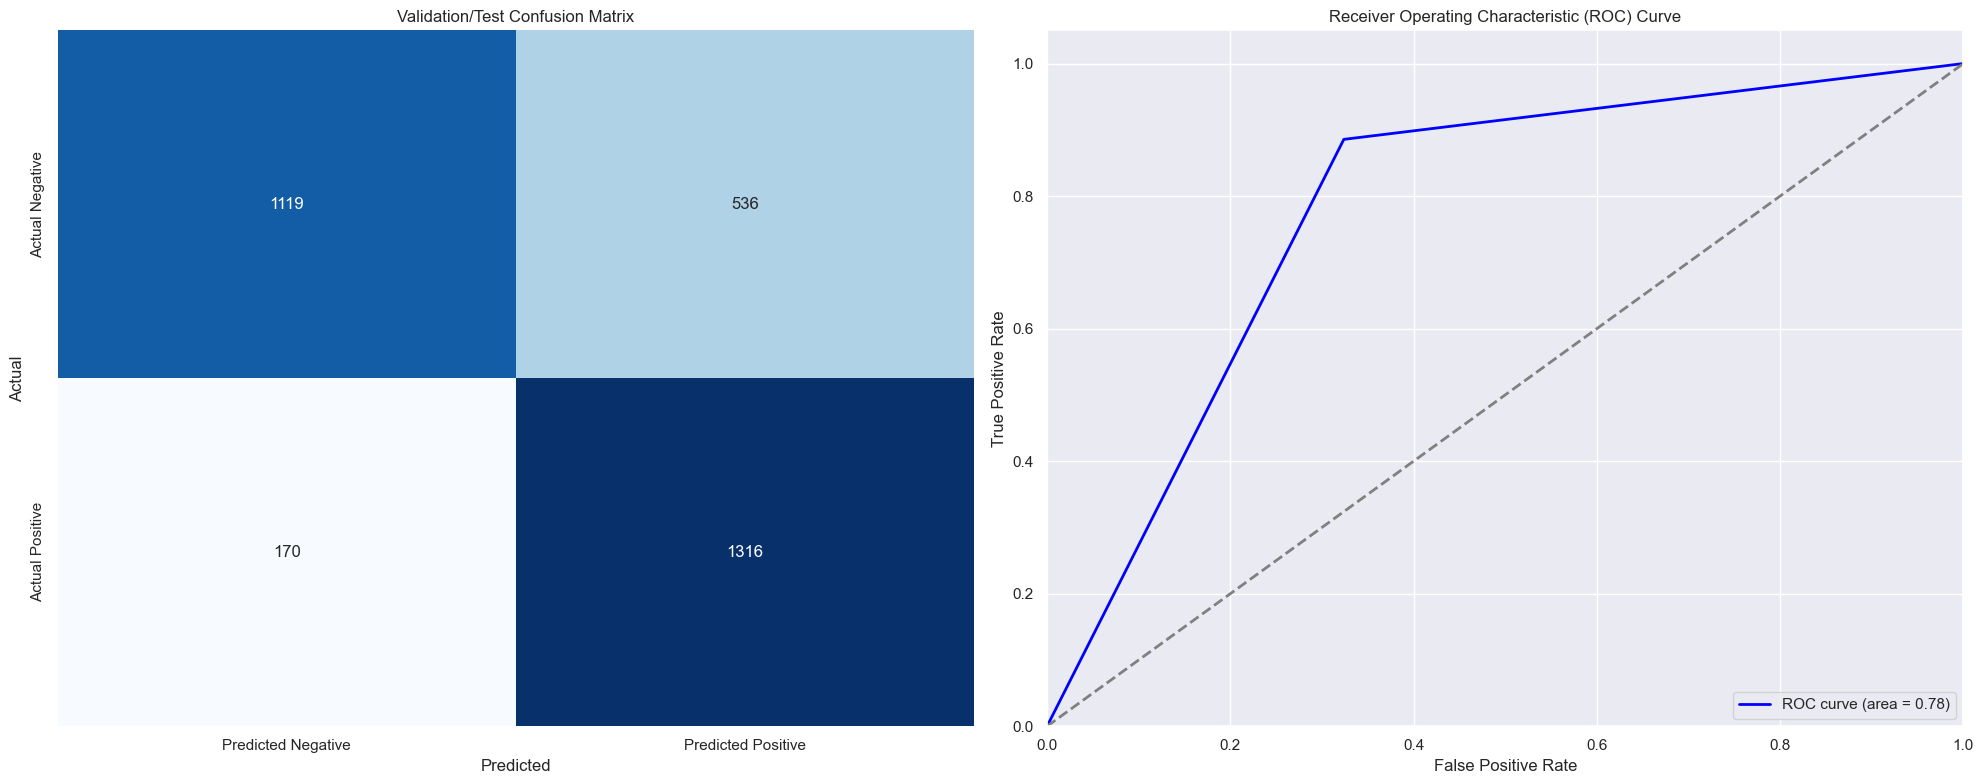

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866


In [18]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

### XGBClassifier

#### Explanation of the Gamma Parameter
- In XGBoost, the regularization term that controls the minimum loss reduction required to make a split at a node is known as the "gamma" parameter. This parameter plays a crucial role in the decision-making process of the algorithm during the tree construction phase.
- Definition: The gamma parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. If the reduction in loss from making a split is less than gamma, then that split will not be made.
- Purpose: By setting a higher value for gamma, you can prevent overfitting by making the model more conservative. It effectively controls how complex the model can become by limiting the number of splits. A lower gamma allows more splits and can lead to a more complex model.
- Impact on Model Complexity:
    - High Gamma Value: Results in fewer splits, leading to simpler trees that may underfit the data.
    - Low Gamma Value: Allows more splits, potentially leading to more complex trees that may overfit the training data.

The gamma parameter is essential for controlling the complexity of models built using XGBoost by regulating how much improvement in loss is necessary for splitting nodes. Adjusting this parameter can help balance between bias and variance, thus improving model performance on unseen data.

In [19]:
# import library
from xgboost import XGBClassifier

# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the hyperparameter grid to search
parameters = dict(
n_estimators = [50, 100, 200],
max_depth = [3, 5],
learning_rate = [0.01, 0.05, 0.1],
subsample = [0.4, 0.7],
gamma = [0.8, 1, 5]   # regularization term that controls the minimum loss reduction required to make a split at a node.
)

# Base Model
xgb_param = {'scale_pos_weight': scale_pos_weight, 'n_jobs': -1, 'random_state': RANDOM_STATE}

# instantiate XGB Classifier
model = XGBClassifier(**xgb_param)

# CV with grid search for Hyper-Parameter tuning
xgb_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = xgb_fit.best_estimator_

CV accuracy: 0.778 +/- 0.011


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [20]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.8, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, random_state=1776, ...)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.73      0.80      6619
        True       0.75      0.90      0.82      5941

    accuracy                           0.81     12560
   macro avg       0.82      0.81      0.81     12560
weighted avg       0.82      0.81      0.81     12560



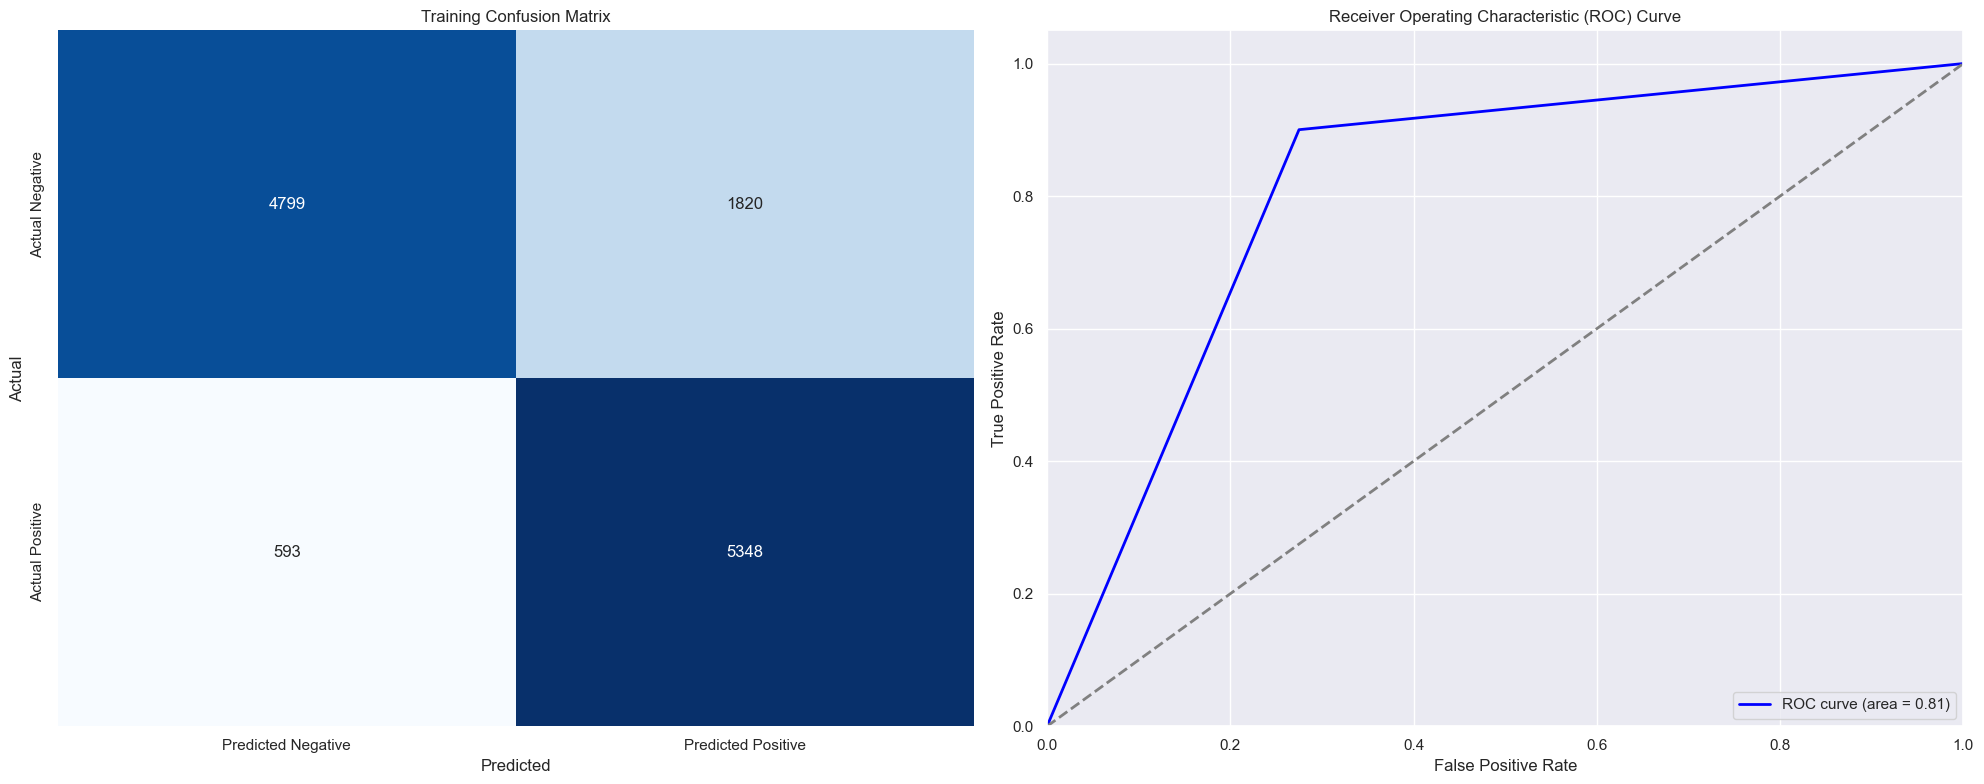

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610


In [21]:
# initialize variables
Algorithm = 'XGBClassifier'
Desc = 'XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed'
Model = 'xgb_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.69      0.77      1655
        True       0.72      0.88      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.79      0.78      3141
weighted avg       0.80      0.78      0.78      3141



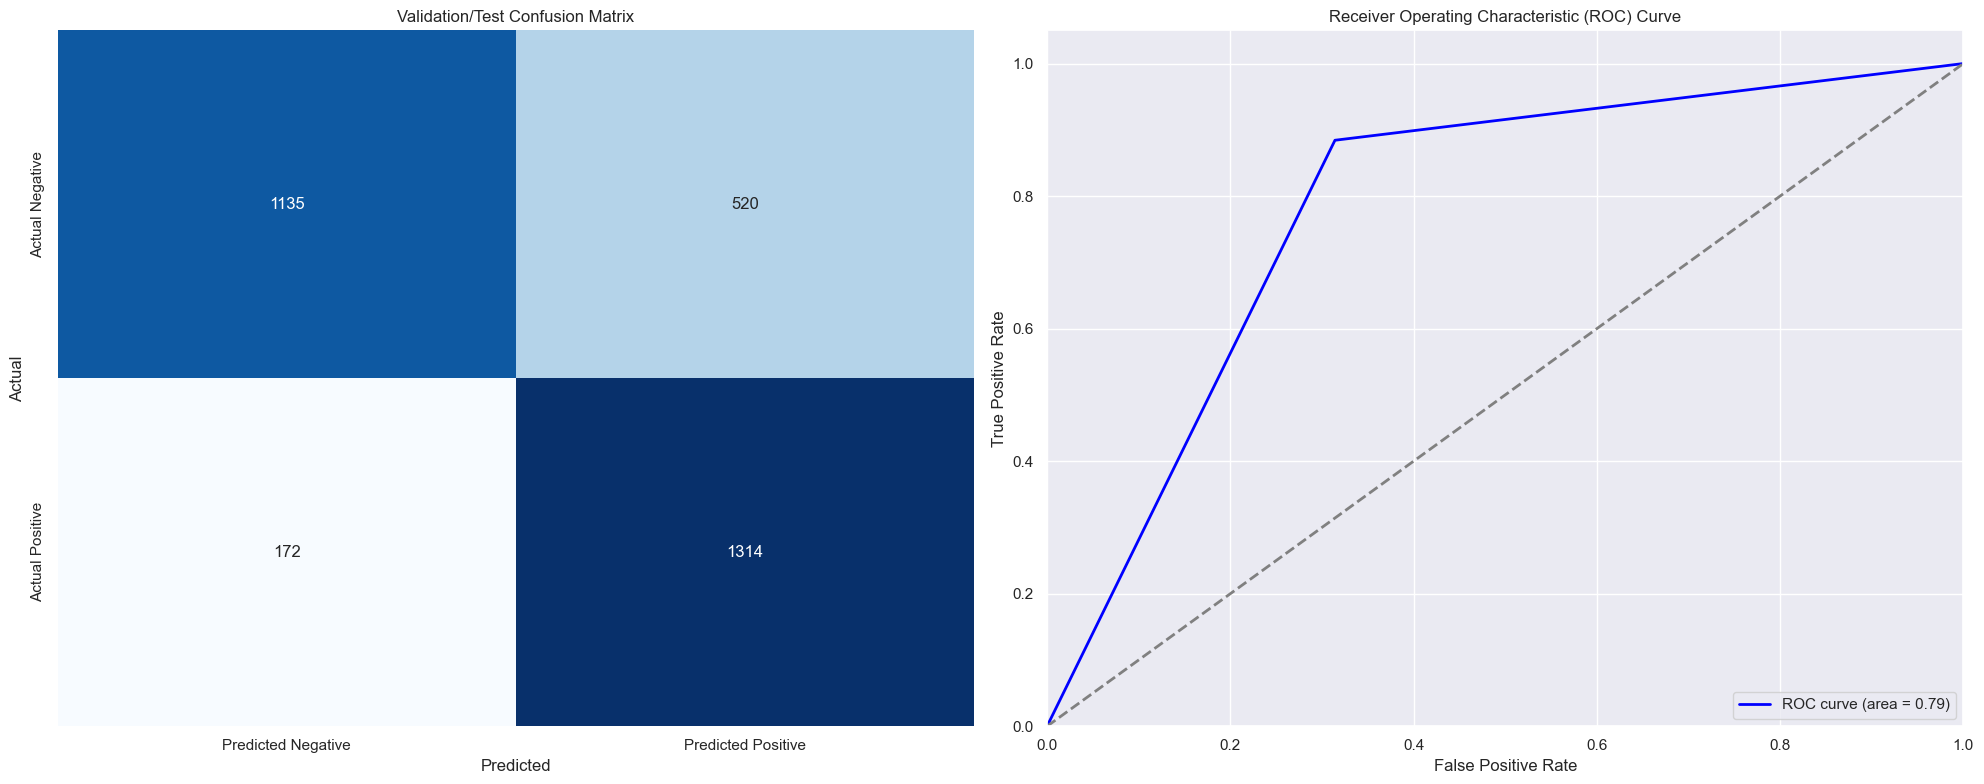

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027


In [22]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

### AdaBoostClassifier

In [23]:
# import library
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 1.0]
}
# base estimater
estimator = DecisionTreeClassifier(max_depth=1)

# create a AdaBoost model
model = AdaBoostClassifier(estimator=estimator, algorithm='SAMME', random_state=RANDOM_STATE)

# CV with grid search for Hyper-Parameter tuning
ada_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = ada_fit.best_estimator_

CV accuracy: 0.769 +/- 0.009


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [24]:
print(model)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=200, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.65      0.75      6619
        True       0.70      0.90      0.79      5941

    accuracy                           0.77     12560
   macro avg       0.79      0.78      0.77     12560
weighted avg       0.79      0.77      0.77     12560



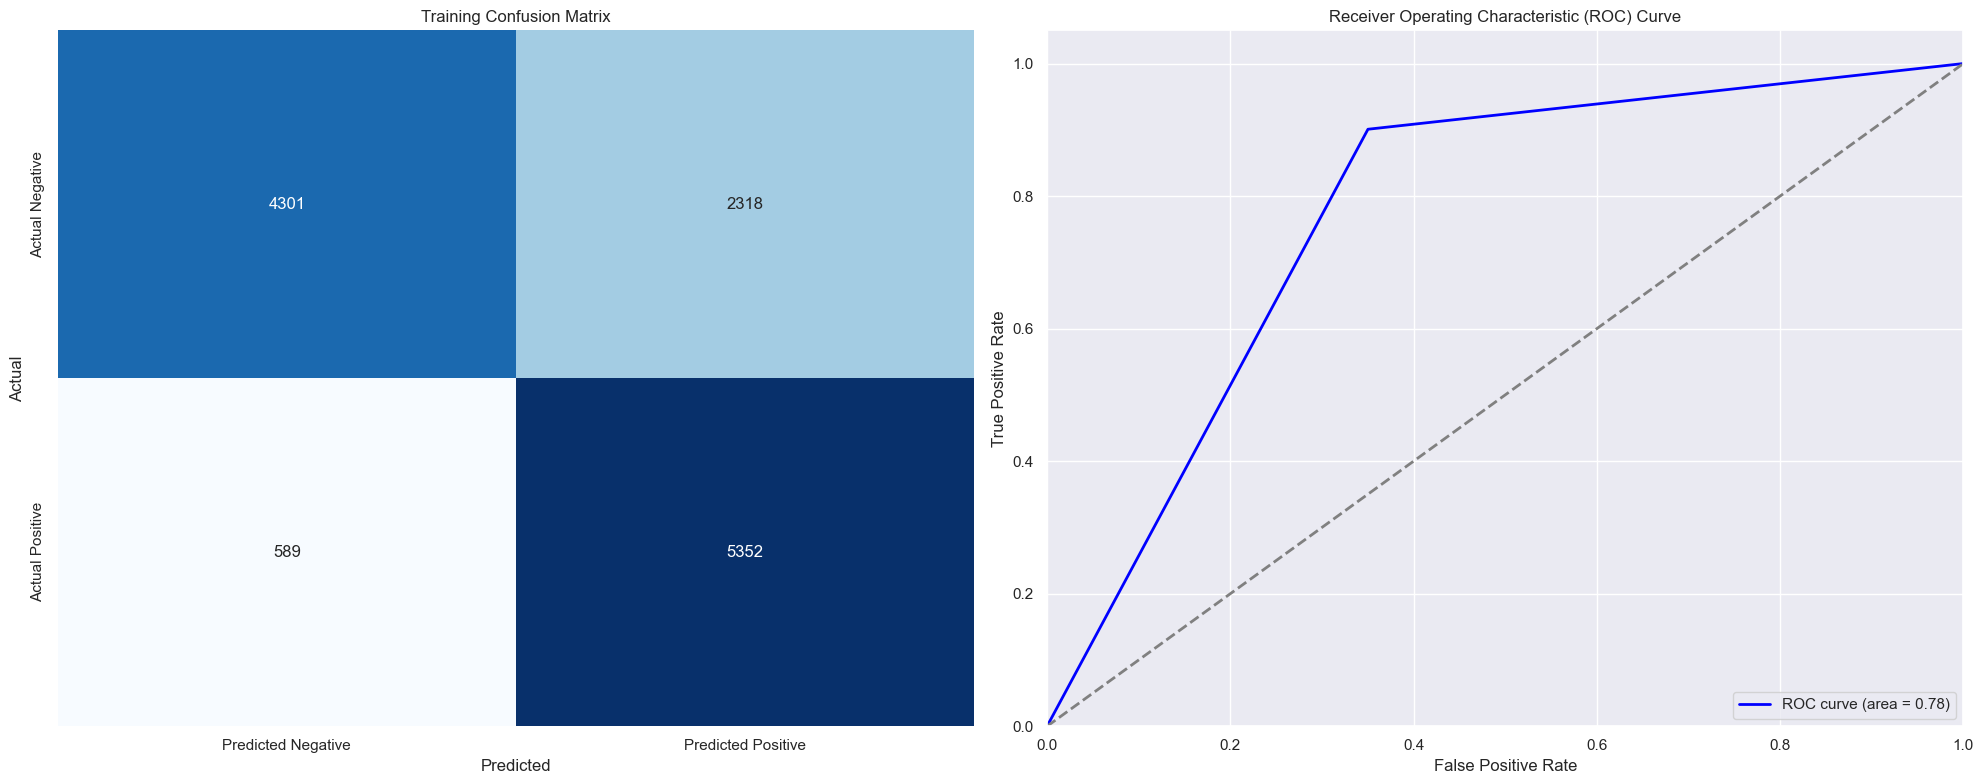

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327


In [25]:
# initialize variables
Algorithm = 'AdaBoost'
Desc = 'AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed'
Model = 'ada_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.65      0.75      1655
        True       0.70      0.91      0.79      1486

    accuracy                           0.77      3141
   macro avg       0.79      0.78      0.77      3141
weighted avg       0.80      0.77      0.77      3141



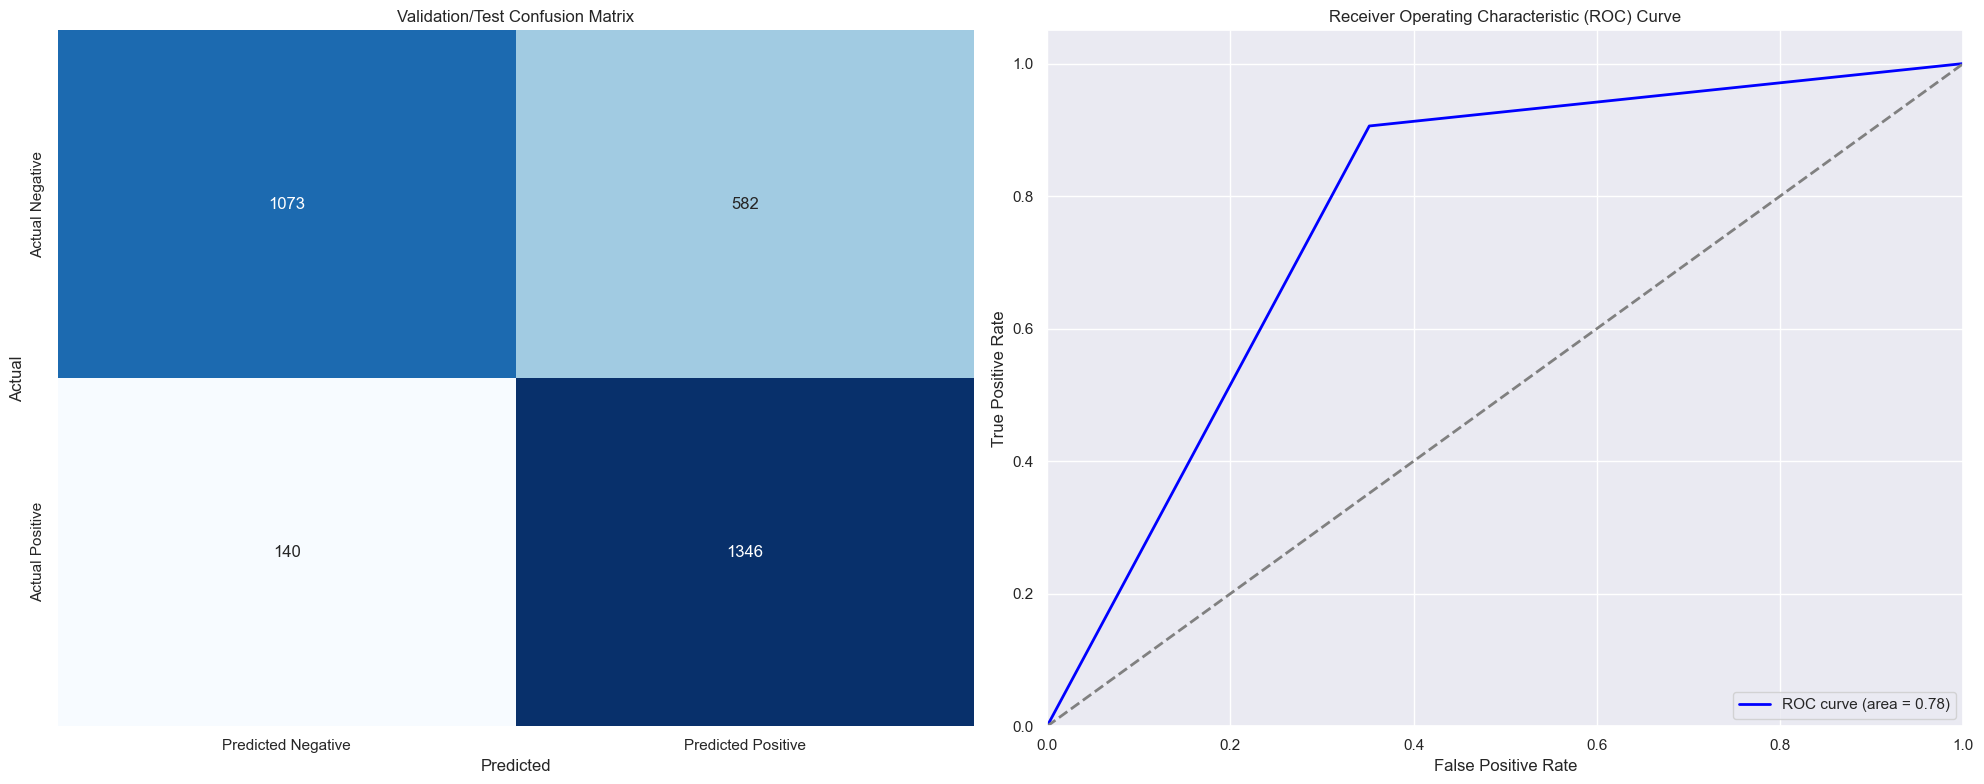

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063


In [26]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

### Stacking Classifier
- Both AdaBoost and XGBoost are boosting algorithms, but they have key differences:
    - AdaBoost: Focuses on reducing bias by reweighting misclassified samples, works well with weak learners.
        - AdaBoost → Handles noisy datasets and works well with simpler decision stumps. 
    - XGBoost: A gradient boosting algorithm that minimizes loss efficiently using second-order derivatives and feature importance techniques.
        - XGBoost → Captures complex patterns, handles missing values, and optimizes performance.
    - Random Forest is a bagging-based algorithm that reduces variance and is more robust to noise.

In [27]:
# import library
from sklearn.ensemble import StackingClassifier

# best model
AdaModel = ada_fit.best_estimator_
XGBModel = xgb_fit.best_estimator_

# filt model
AdaModel.fit(X_train, y_train)
XGBModel.fit(X_train, y_train)

# create meta-model
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('adaboost', AdaModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# Fit the stacking ensemble
stack_AdaXgb = stacking_ensemble.fit(X_train, y_train)

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.75      0.81      6619
        True       0.76      0.89      0.82      5941

    accuracy                           0.82     12560
   macro avg       0.82      0.82      0.82     12560
weighted avg       0.83      0.82      0.82     12560



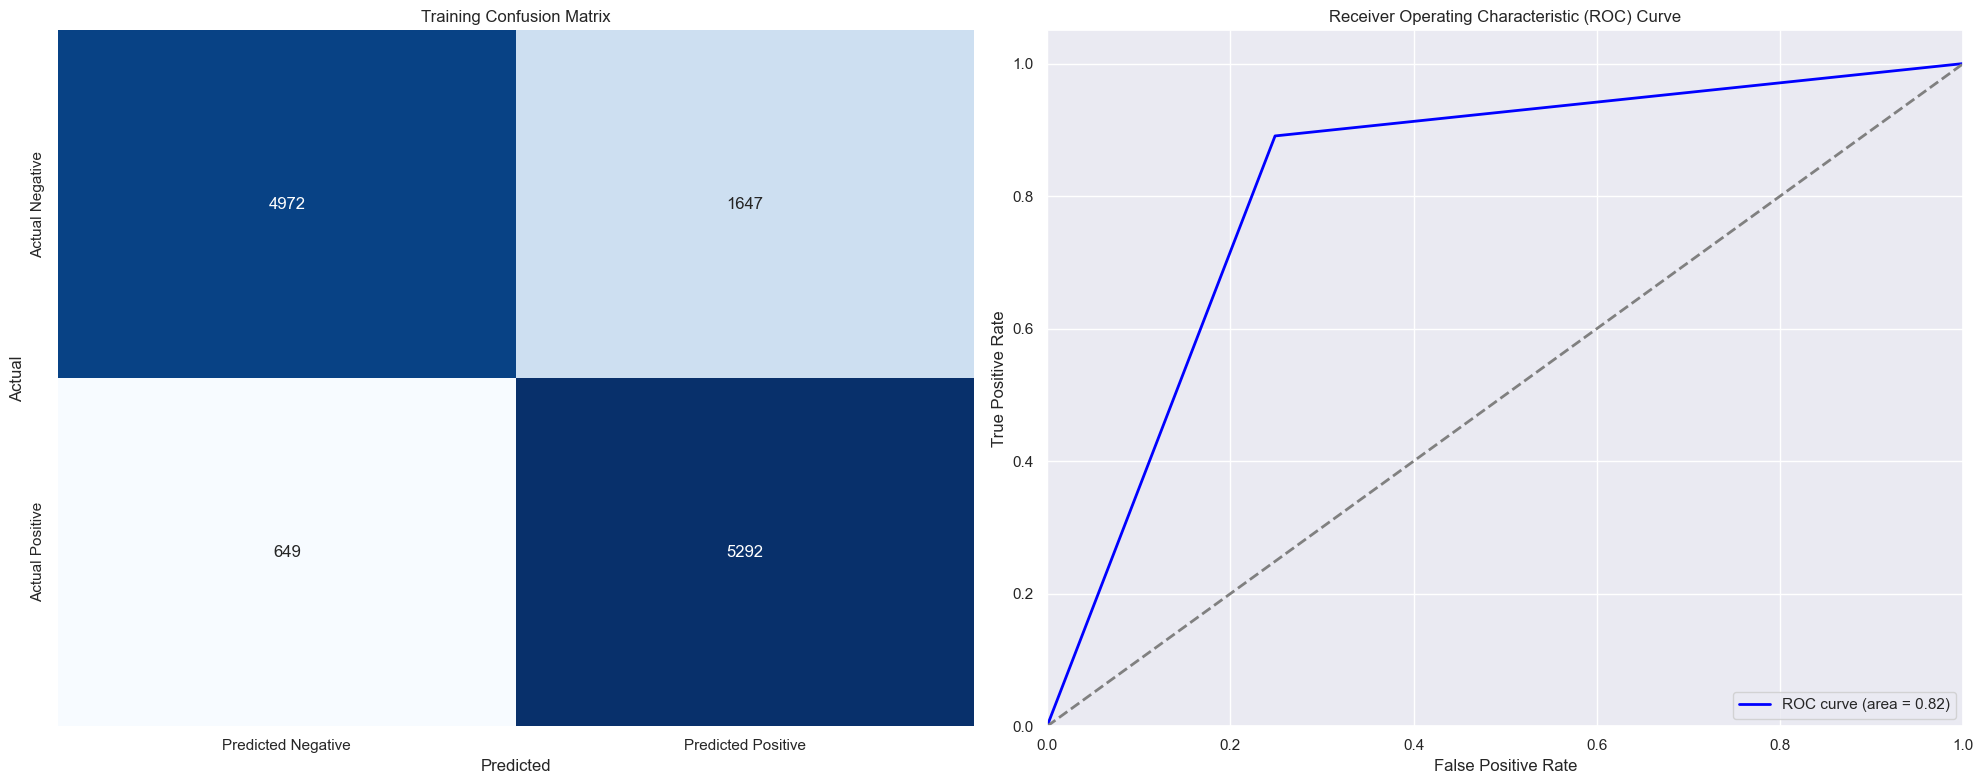

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965


In [28]:
# initialize variables
Algorithm = 'Stacking(AdaBoost & XGBoost)'
Desc = 'Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed'
Model = 'stack_AdaXgb'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_AdaXgb, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.70      0.77      1655
        True       0.72      0.87      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.79      0.78      3141
weighted avg       0.80      0.78      0.78      3141



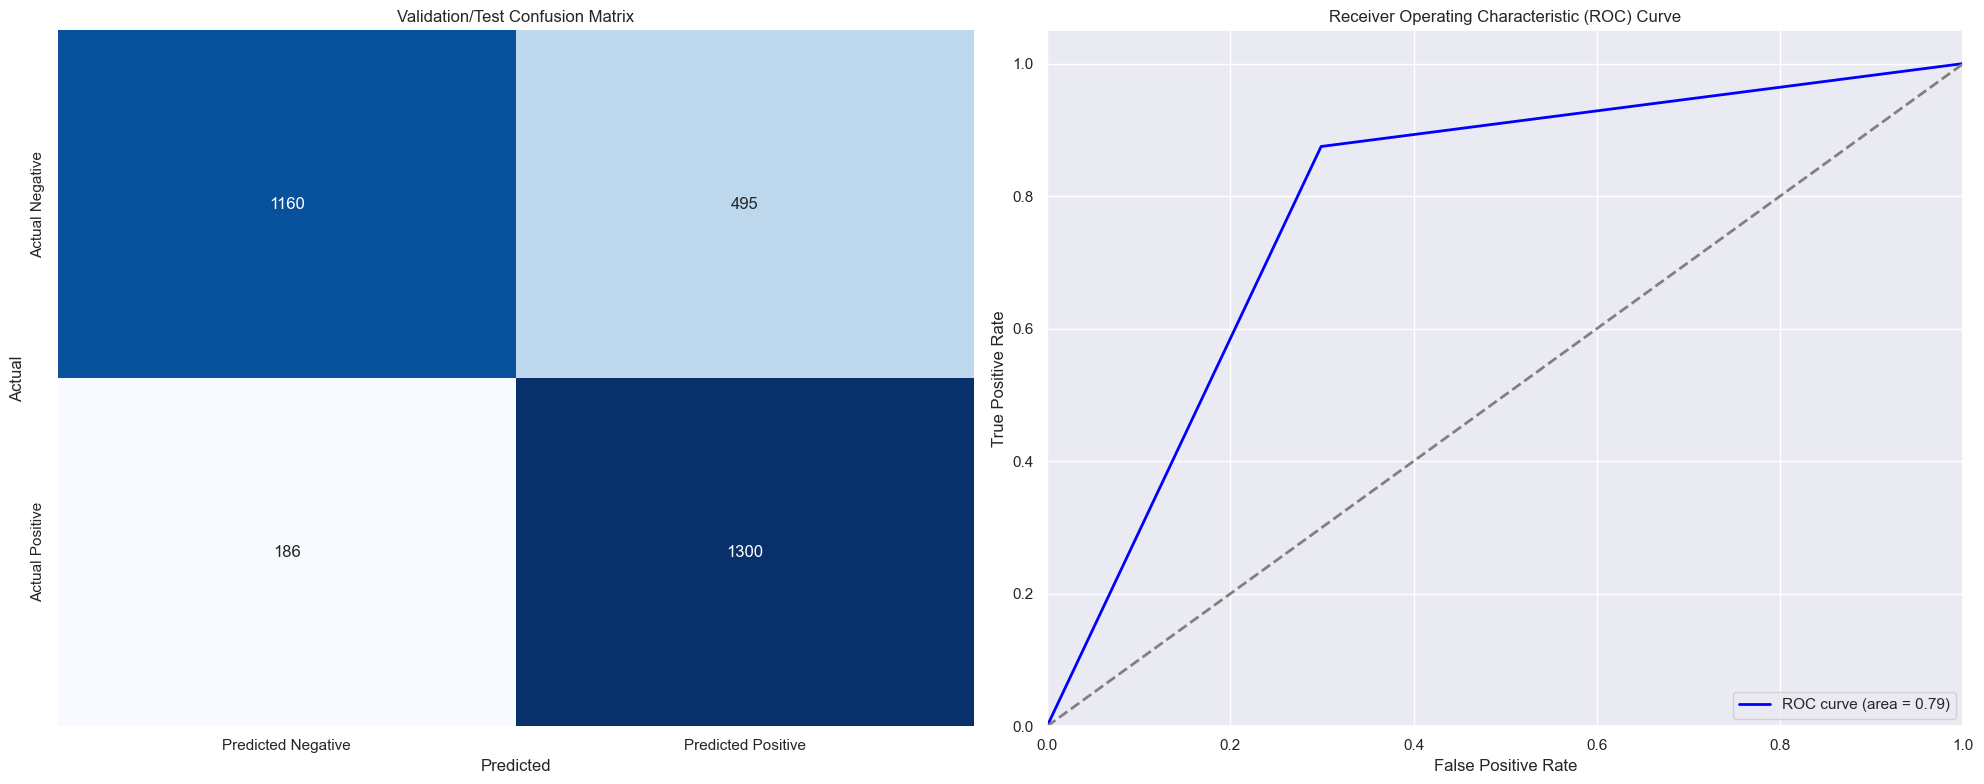

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965
9,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783190,0.874832,0.792441,0.692800,0.724234,0.700906,0.787869


In [29]:
# initialize variables
Type = 'Validation/test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_AdaXgb, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

In [30]:
RFCModel = rfc_fit.best_estimator_
XGBModel = xgb_fit.best_estimator_

# filt model
RFCModel.fit(X_train, y_train)
XGBModel.fit(X_train, y_train)

# create meta-model
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('randomforest', RFCModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# fit the stacking ensemble
stack_RfcXgb = stacking_ensemble.fit(X_train, y_train)

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.75      0.81      6619
        True       0.76      0.89      0.82      5941

    accuracy                           0.81     12560
   macro avg       0.82      0.82      0.81     12560
weighted avg       0.82      0.81      0.81     12560



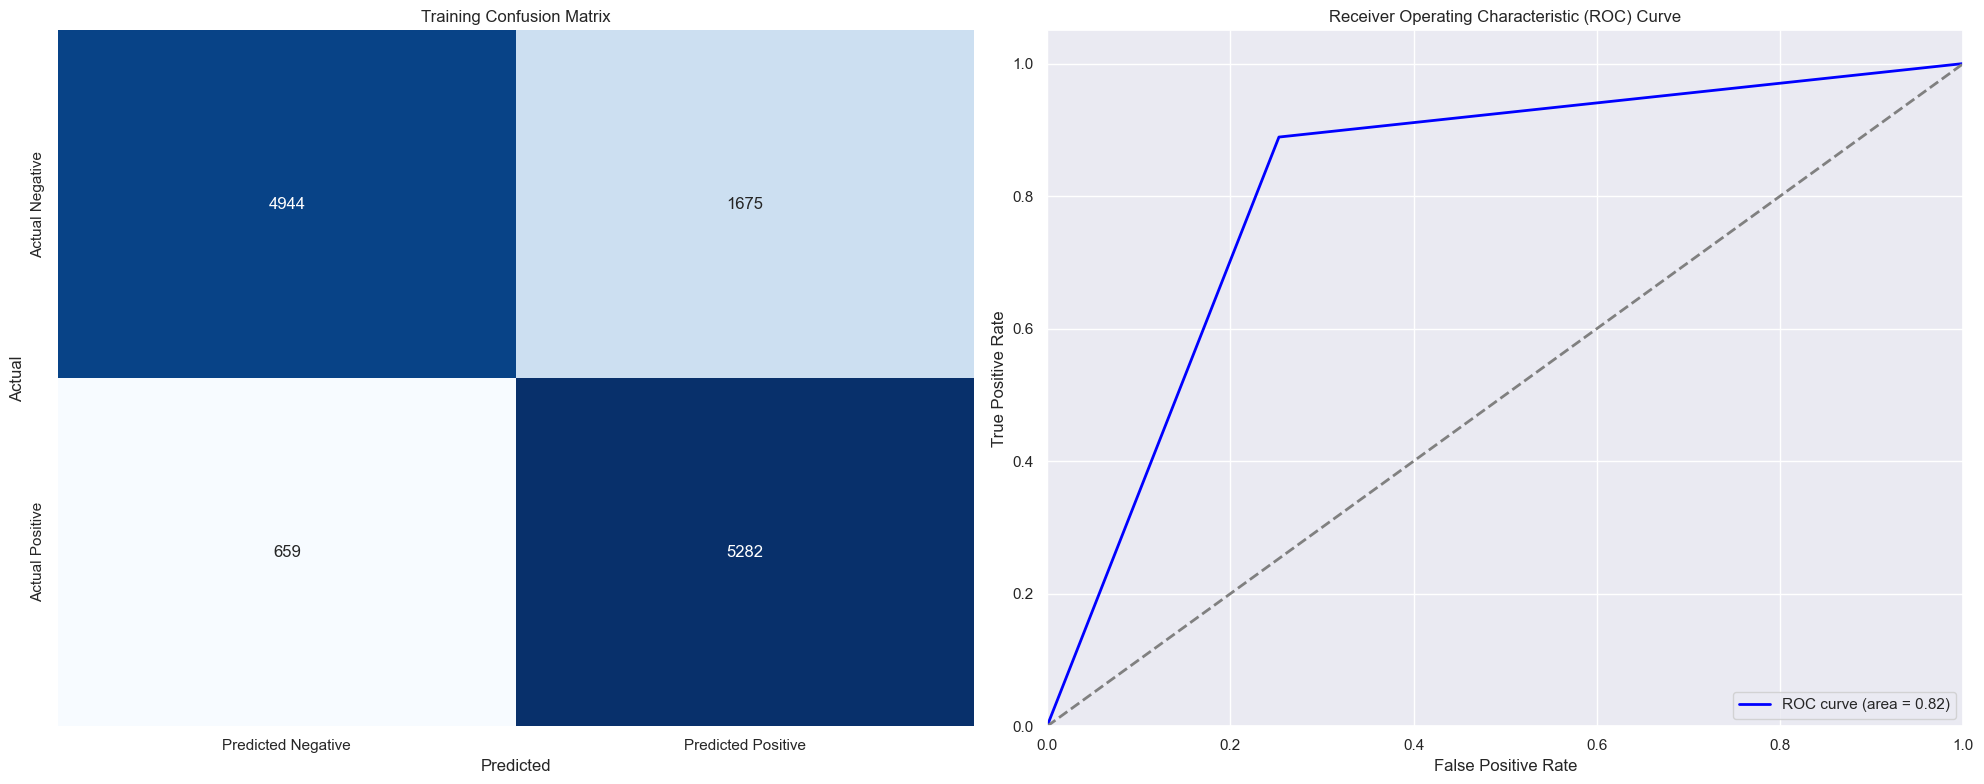

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965
9,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783190,0.874832,0.792441,0.692800,0.724234,0.700906,0.787869


In [31]:
# initialize variables
Algorithm = 'Stacking(RandomForest & XGBoost)'
Desc = 'Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed'
Model = 'stack_AdaXgb'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_RfcXgb, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.70      0.77      1655
        True       0.72      0.87      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.79      0.78      3141
weighted avg       0.80      0.78      0.78      3141



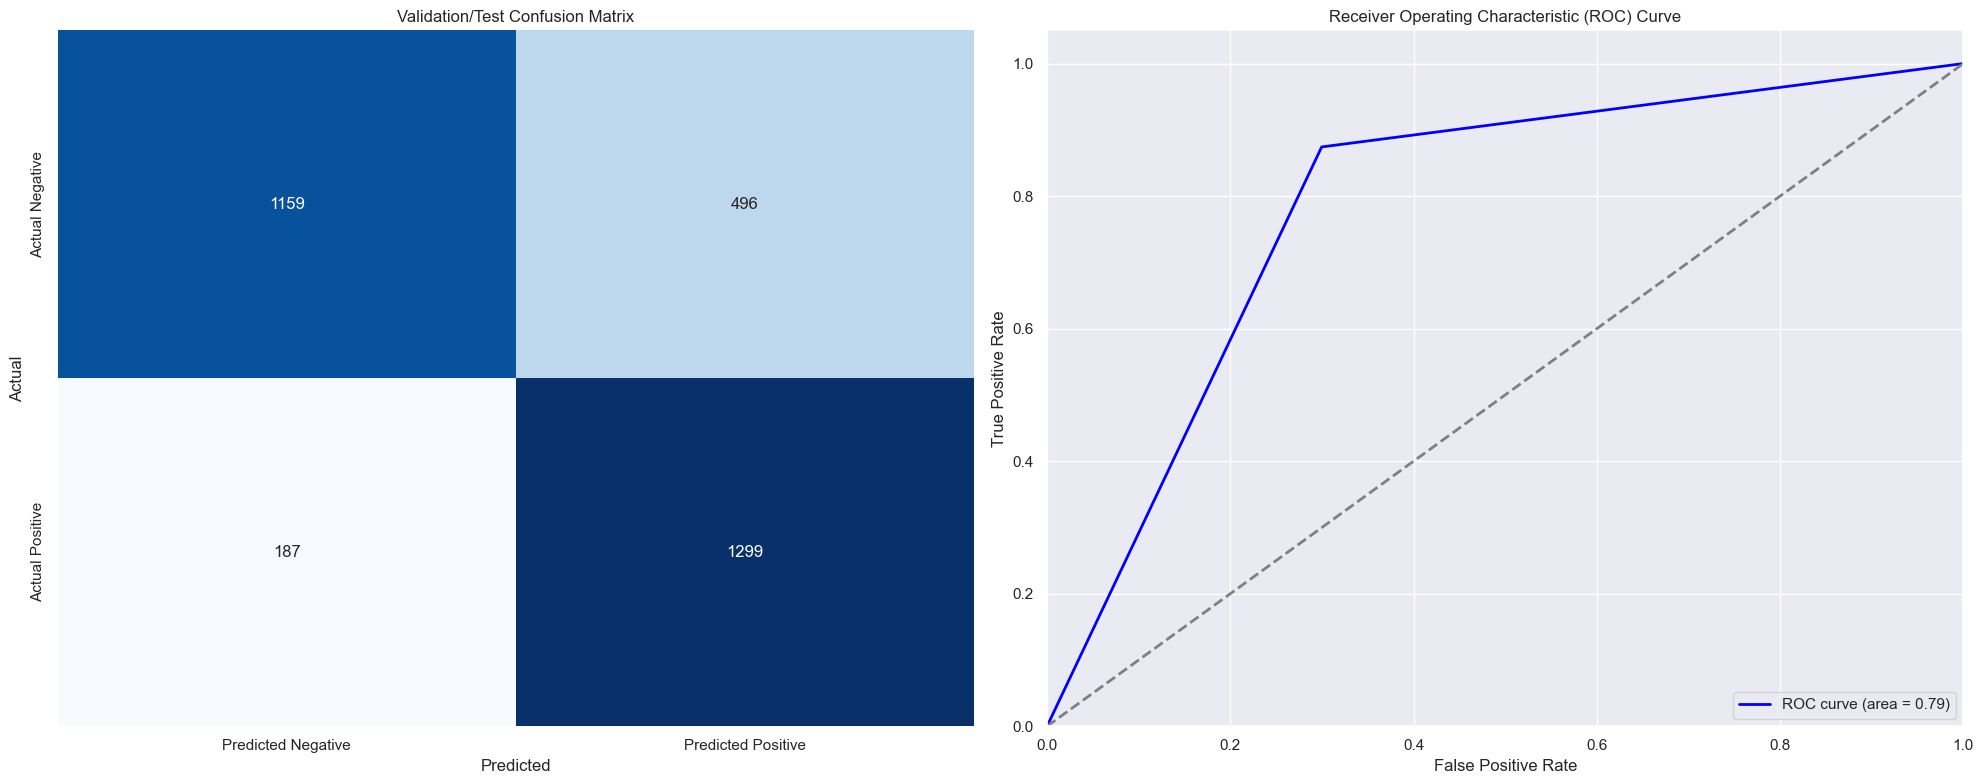

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965
9,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783190,0.874832,0.792441,0.692800,0.724234,0.700906,0.787869


In [32]:
# initialize variables
Type = 'Validation/test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_RfcXgb, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

#### Hyper-Paramater Grid Search

In [40]:
# paramater search
parameters = dict(
C = list(np.round(np.linspace(0.01, 1),2))
)
# Base Model
lrc_param = {'max_iter':10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# create meta-model
meta_model = LogisticRegression(**lrc_param)

# CV with grid search for Hyper-Parameter tuning
meta_model_fit = umf.stratified_grid(meta_model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
meta_model = meta_model_fit.best_estimator_

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('adaboost', AdaModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# fit the stacking ensemble
stack_GS_AdaXgb = stacking_ensemble.fit(X_train, y_train)

CV accuracy: 0.772 +/- 0.010


In [41]:
print( stack_GS_AdaXgb)

StackingClassifier(cv=5,
                   estimators=[('adaboost',
                                AdaBoostClassifier(algorithm='SAMME',
                                                   estimator=DecisionTreeClassifier(max_depth=1),
                                                   n_estimators=200,
                                                   random_state=1776)),
                               ('xgboost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_...
                                          

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.72      0.80      6619
        True       0.75      0.90      0.81      5941

    accuracy                           0.81     12560
   macro avg       0.82      0.81      0.81     12560
weighted avg       0.82      0.81      0.81     12560



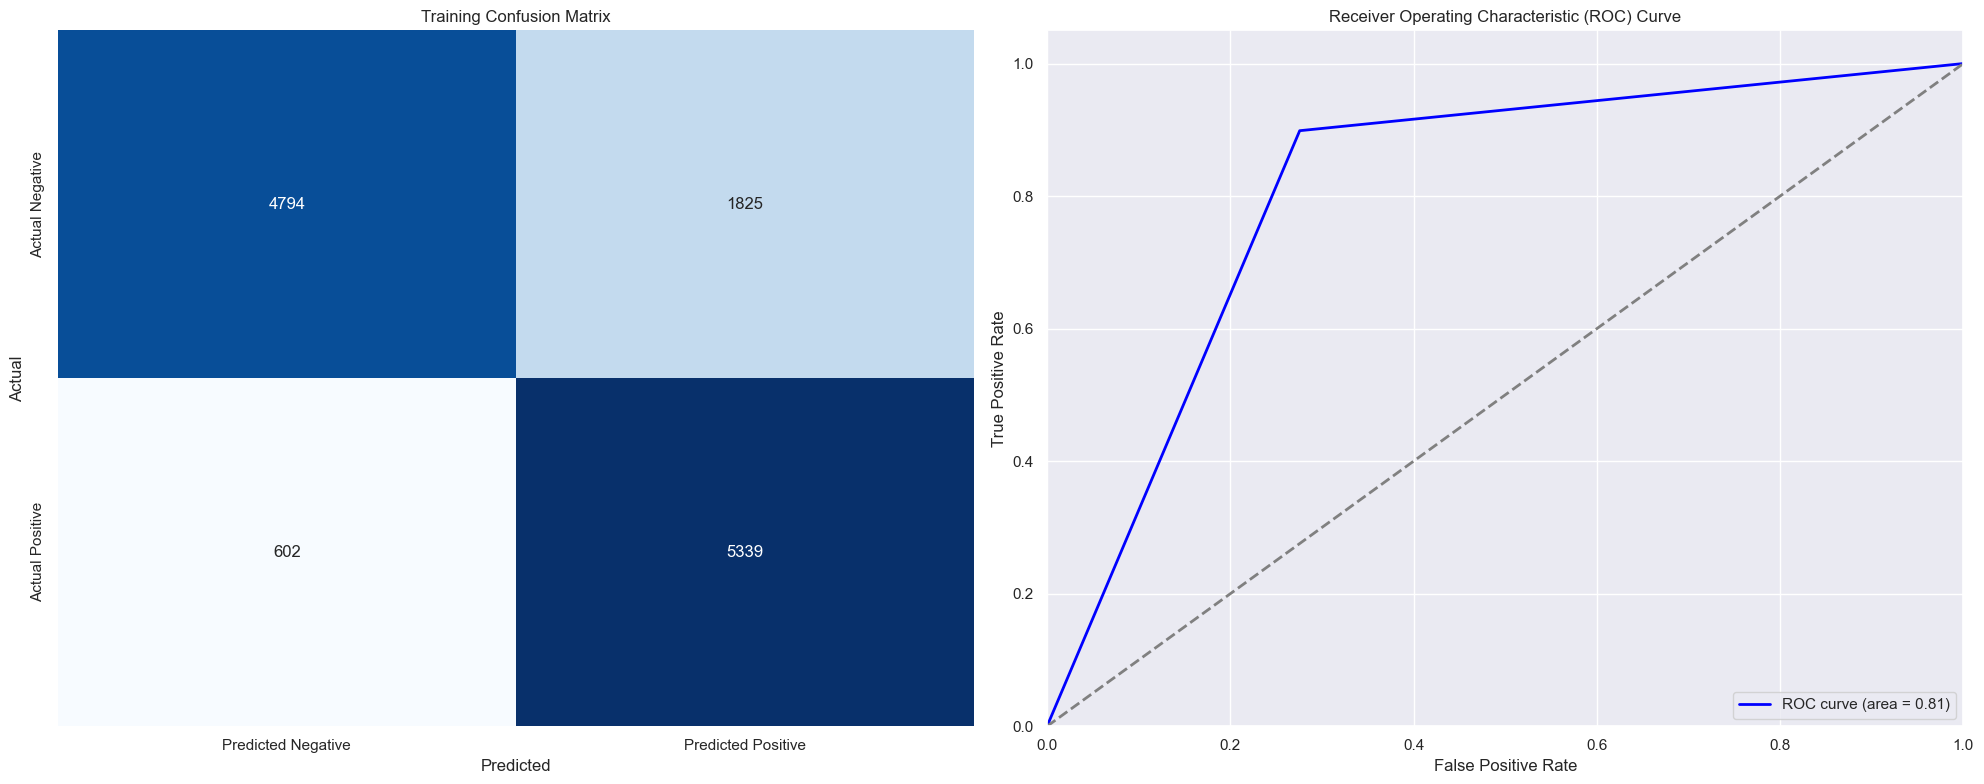

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965
9,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783190,0.874832,0.792441,0.692800,0.724234,0.700906,0.787869


In [42]:
# initialize variables
Algorithm = 'Stacking(AdaBoost & XGBoost)'
Desc = 'Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed'
Model = 'stack_GS_AdaXgb'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_GS_AdaXgb, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.69      0.77      1655
        True       0.72      0.88      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.79      0.78      3141
weighted avg       0.80      0.78      0.78      3141



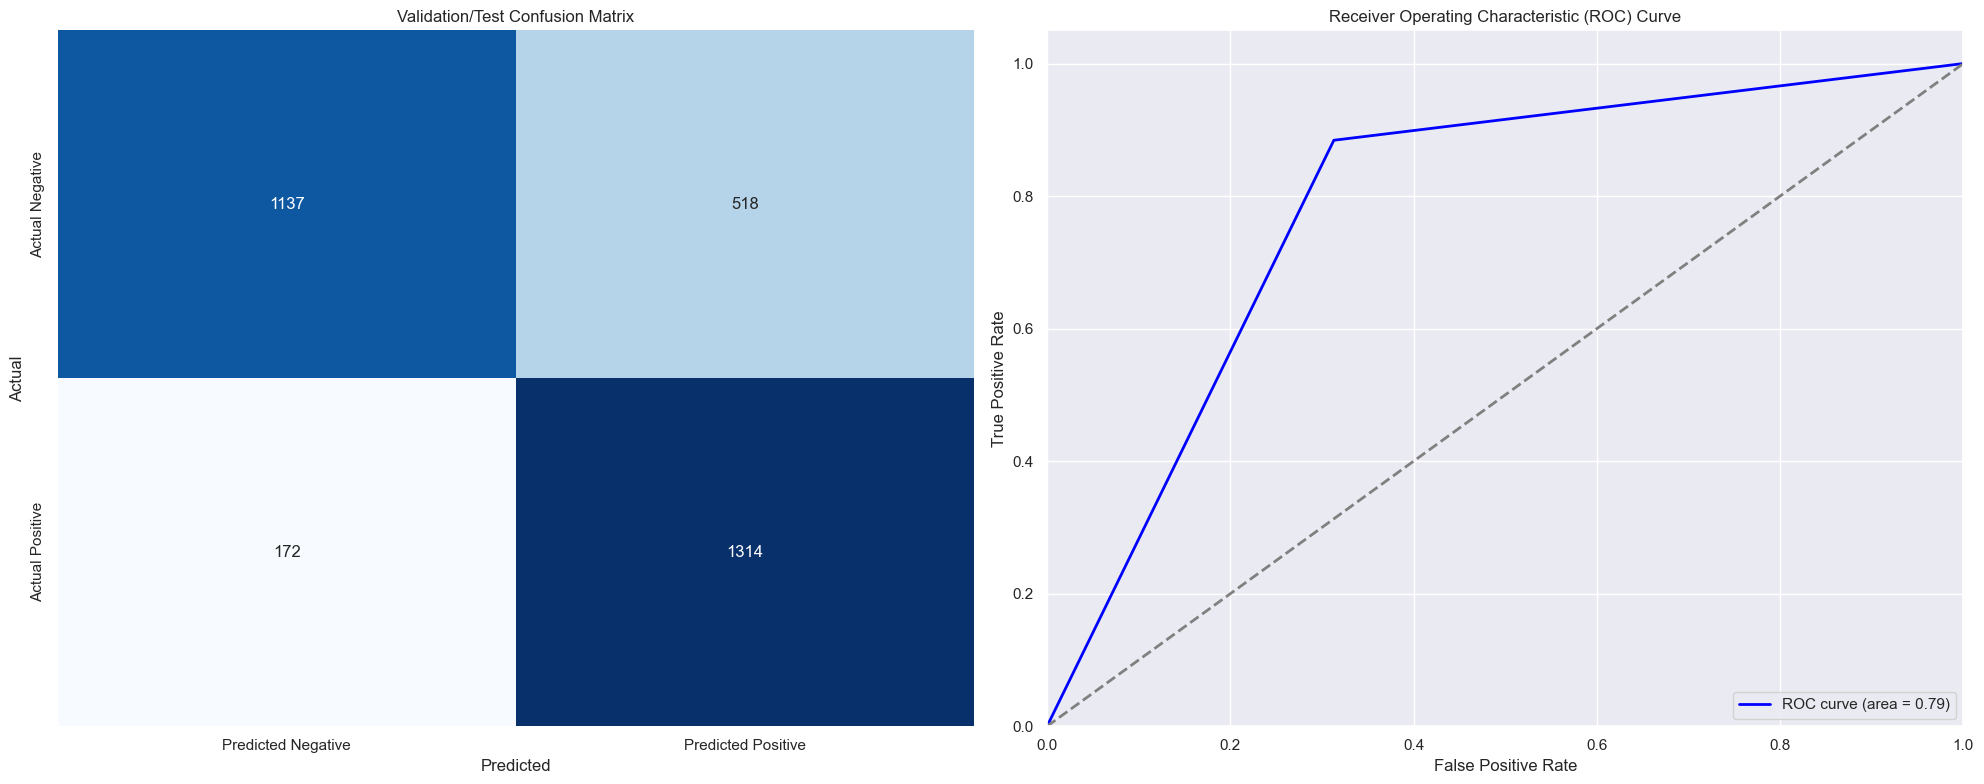

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965
9,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783190,0.874832,0.792441,0.692800,0.724234,0.700906,0.787869


In [43]:
# initialize variables
Type = 'Validation/test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_GS_AdaXgb, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

#### Hyper-Paramater Random Search

In [44]:
# import library
from sklearn.model_selection import RandomizedSearchCV

# parameter distribution for RandomizedSearchCV
param_dist = {
    'C': list(np.round(np.linspace(0.01, 1, 20), 2))  # 20 evenly spaced values between 0.01 and 1
}

# base Model parameters
lrc_param = {'max_iter': 10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# Create initial meta-model
meta_model = LogisticRegression(**lrc_param)

# perform Randomized Search for Hyperparameter tuning
random_search = RandomizedSearchCV(
    meta_model,
    param_distributions=param_dist,
    n_iter=10,  # Number of random combinations to try
    cv=5,
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# fit RandomizedSearchCV on training data
random_search.fit(X_train, y_train)

# get the best estimator from Randomized Search
best_meta_model = random_search.best_estimator_

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('adaboost', AdaModel), ('xgboost', XGBModel)],
    final_estimator=best_meta_model,
    cv=5
)

# fit the stacking ensemble
stack_RS_AdaXgb = stacking_ensemble.fit(X_train, y_train)

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.73      0.80      6619
        True       0.75      0.90      0.82      5941

    accuracy                           0.81     12560
   macro avg       0.82      0.82      0.81     12560
weighted avg       0.82      0.81      0.81     12560



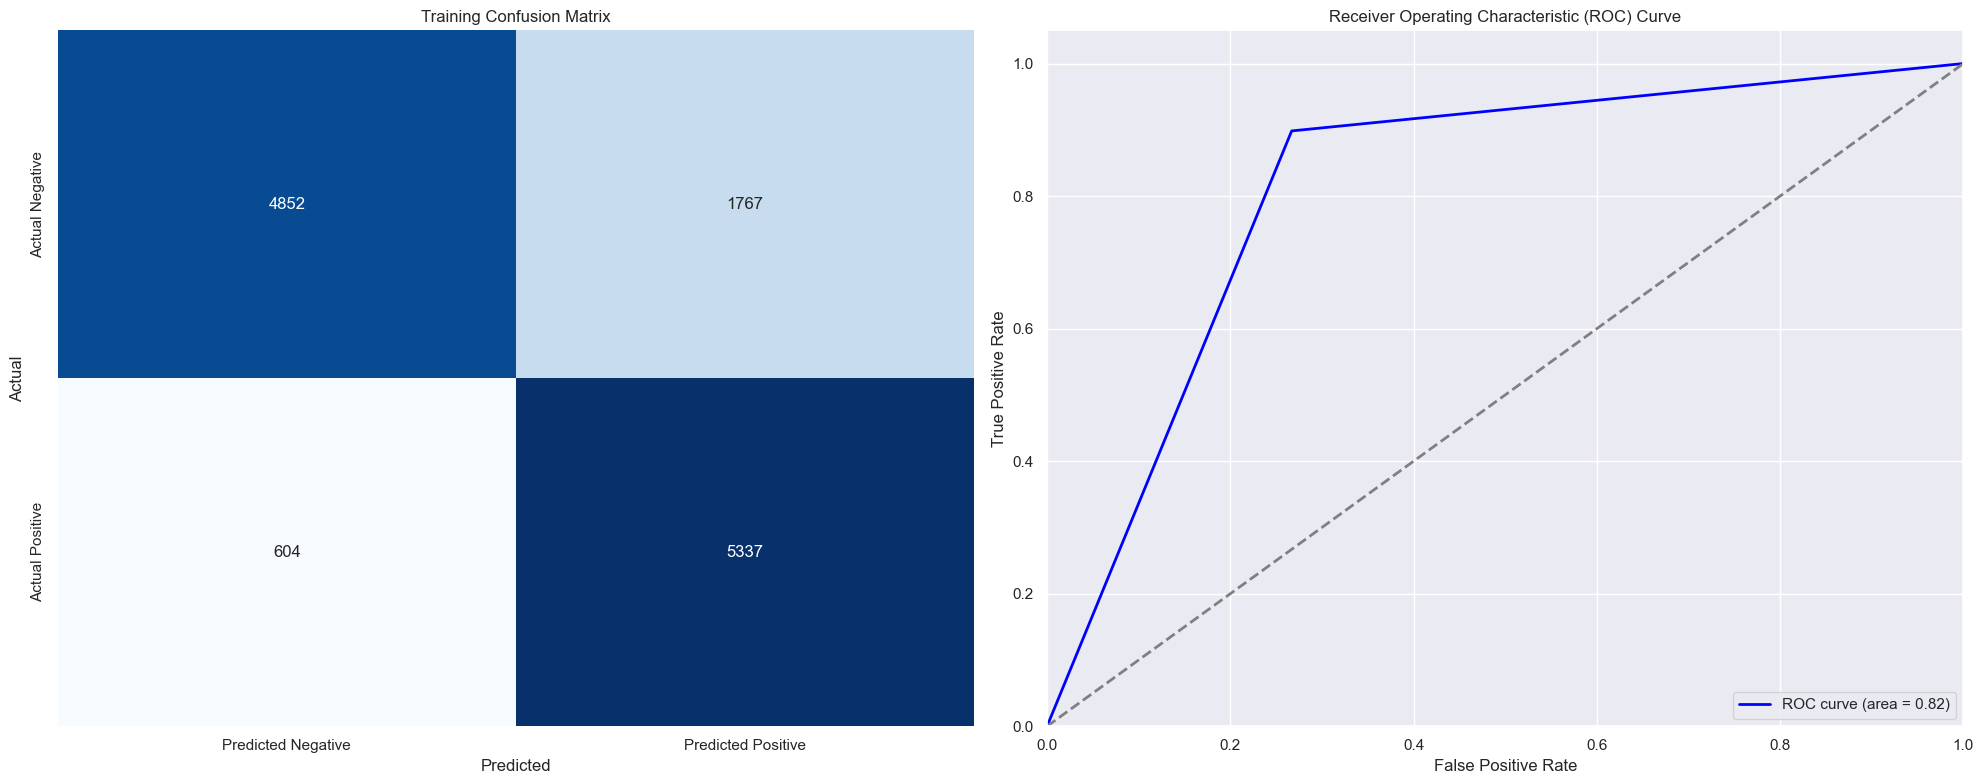

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965
9,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783190,0.874832,0.792441,0.692800,0.724234,0.700906,0.787869


In [45]:
# initialize variables
Algorithm = 'Stacking(AdaBoost & XGBoost)'
Desc = 'Stacking - DONOR - Random Search - Features where variance <= 0.01 removed'
Model = 'stack_RS_AdaXgb'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_RS_AdaXgb, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.69      0.77      1655
        True       0.72      0.88      0.79      1486

    accuracy                           0.78      3141
   macro avg       0.79      0.79      0.78      3141
weighted avg       0.80      0.78      0.78      3141



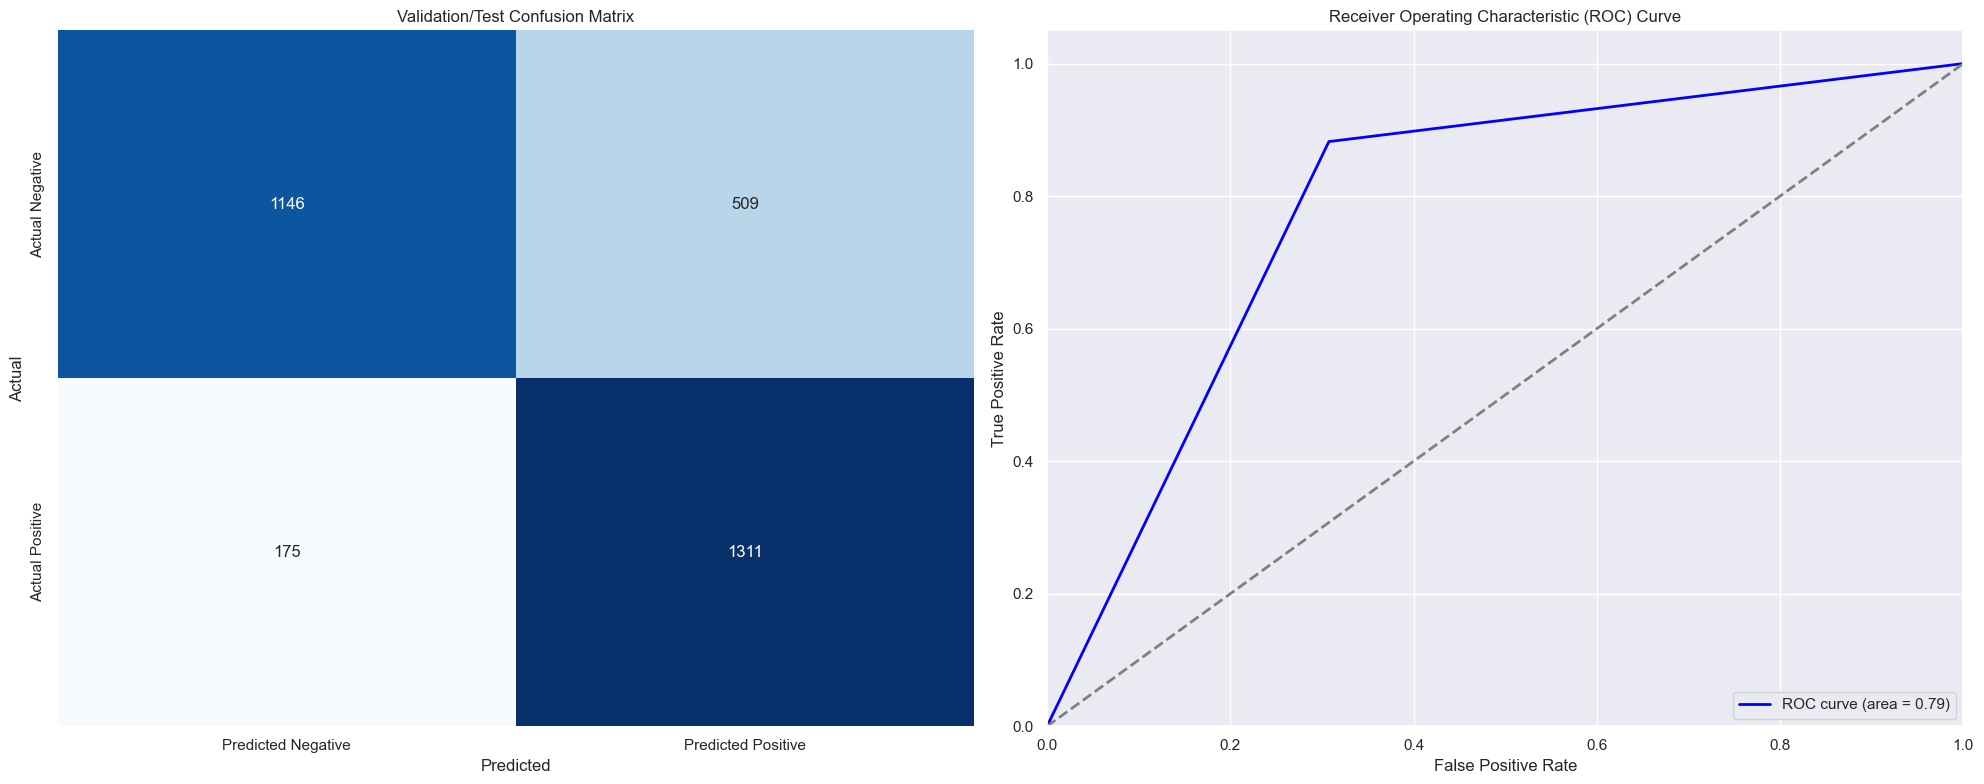

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.779459,0.877293,0.790056,0.688464,0.718599,0.691645,0.784469
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775868,0.878197,0.787568,0.684565,0.713895,0.683988,0.781092
2,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.776433,0.879482,0.788203,0.685036,0.714090,0.683940,0.781711
3,LogisticRegression,lrc_fit,LogisticRegression - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.775231,0.885599,0.788496,0.683415,0.710583,0.676133,0.780866
4,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.807882,0.900185,0.815928,0.718836,0.746094,0.725034,0.812610
5,XGBClassifier,xgb_fit,XGBClassifier - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.779688,0.884253,0.791566,0.688298,0.716467,0.685801,0.785027
6,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.768551,0.900858,0.786423,0.675499,0.697784,0.649796,0.775327
7,AdaBoost,ada_fit,AdaBoost - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.770137,0.905787,0.788518,0.676932,0.698133,0.648338,0.777063
8,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Training,0.817197,0.890759,0.821739,0.731006,0.762646,0.751171,0.820965
9,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking - DONOR - Grid Search - Features where variance <= 0.01 removed,Validation/test,0.783190,0.874832,0.792441,0.692800,0.724234,0.700906,0.787869


In [46]:
# initialize variables
Type = 'Validation/test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_RS_AdaXgb, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

In [ ]:
# Drop rows with index 10 to 13
df_classfication = df_classfication.drop(index=range(12, 14))
# Reset the index
df_classfication = df_classfication.reset_index(drop=True)

In [47]:
df_both

,column
0,BloodGroupMatchLevel
1,MismatchLevel_AMIS
2,MismatchLevel_HLMIS
3,MismatchLevel_BMIS
4,MismatchLevel_DRMIS
5,TransplantRegion
6,CrossMatchDone
7,DistanceFromDonorHospitaltoTXCenter_CAT
8,IschemicTimeHour_CAT
9,Citizenship_Difference


# Hold

In [ ]:
def LogisticFeatureImportance(model, figsize=(8,10), fontsize=8):
    """
    This function analyzes the importance of features in a logistic regression model by processing its 
    coefficients. It creates a DataFrame with each feature's name, coefficient, effect description, 
    odds ratio, percentage change in odds, and probability, including a horizontal bar plot of feature importance.
    
    Args:
    - model: Trained logistic regression model (e.g., from sklearn).
    - figsize: Tuple defining the figure size for the plot (default: (8, 10)).
    - fontsize: Font size for axis labels and title (default: 8).
    
    Returns:
    - DataFrame: A DataFrame with feature importance details.
    """
    # Check if the model has been fitted and has the coef_ attribute
    if not hasattr(model, 'coef_'):
        raise ValueError("The model must be a fitted logistic regression model.")
    
    # Get feature names and coefficients
    feature_names = model.feature_names_in_
    coefficients = model.coef_
    
    # If it's a multi-class logistic regression, handle each class separately
    if coefficients.ndim > 1:
        coeff_list = []
        for i in range(coefficients.shape[0]):
            class_name = f"Class {i}"
            class_coefficients = coefficients[i]
            coeff_list.append(pd.DataFrame({
                'Feature': feature_names,
                'Coefficient': class_coefficients,
                'Description': ['Decrease in the log-odds of the Positive Class' if x < 0 else 'Increase in the log-odds of the Positive Class' for x in class_coefficients],
                'Odd Ratio': np.exp(class_coefficients),
                'Percentage Change in Odds': (np.exp(class_coefficients) - 1) * 100,
                'Probability': np.exp(class_coefficients) / (1 + np.exp(class_coefficients)),
                'Class': class_name
            }))
        # Concatenate dataframes for all classes
        LRcoeff_df = pd.concat(coeff_list, ignore_index=True)
    else:
        # Single class logistic regression
        LRcoeff_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefficients[0],
            'Description': ['Decrease in the log-odds of the Positive Class' if x < 0 else 'Increase in the log-odds of the Positive Class' for x in coefficients[0]],
            'Odd Ratio': np.exp(coefficients[0]),
            'Percentage Change in Odds': (np.exp(coefficients[0]) - 1) * 100,
            'Probability': np.exp(coefficients[0]) / (1 + np.exp(coefficients[0])),
        })
    
    # Sort by Coefficient for better visualization
    LRcoeff_df = LRcoeff_df.sort_values(by='Coefficient', ascending=False)
    
    # Reset the index
    LRcoeff_df.reset_index(drop=True, inplace=True)
    
    # Plot feature importance (using Odds Ratio for better interpretability)
    plt.figure(figsize=figsize)
    if 'Class' in LRcoeff_df.columns:
        # Plot for multi-class case
        for class_name in LRcoeff_df['Class'].unique():
            class_df = LRcoeff_df[LRcoeff_df['Class'] == class_name]
            plt.barh(class_df['Feature'], class_df['Odd Ratio'], label=class_name)
    else:
        # Single class logistic regression
        plt.barh(LRcoeff_df['Feature'], LRcoeff_df['Odd Ratio'], color='steelblue')
    
    plt.axvline(1, color='red', linestyle='--', label="Odd Ratio = 1 (No Effect)")
    plt.xlabel("Odds Ratio")
    plt.ylabel("Features")
    plt.title("Feature Importance in Logistic Regression")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return LRcoeff_df


In [ ]:
# best model
model = lrc_fit.best_estimator_

In [ ]:
# feature importance & plot
lrc_df = LogisticFeatureImportance(model, figsize=(20,40), fontsize=5)

In [ ]:
lrc_df.head()